In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
import cupy as cp
from cupy.linalg import eigh as cp_eigh

# ============================================================================
# Paramètres fixes
# ============================================================================
alpha   = 1.0
B       = 299
M       = 199
a_grid  = np.linspace(0, 1.0, 100)   # shift de moyenne entre X et Y

n_vals  = [500, 1000]
p_vals  = [100, 500, 1000]

C_CONST = (2.0 / 9.0) * np.exp(3)

def get_eval_grid(p, F0_ppf, lo_q=0.001, hi_q=0.999):
    """
    Grille fixe basée sur les quantiles THEORIQUES de la loi sous H0
    (pas ré-échantillonnée à chaque réplication -> reste comparable d'une
    réplication a l'autre, et n'a aucun impact sur l'axe des abscisses du
    graphique final qui reste a_grid).
    """
    q = np.linspace(lo_q, hi_q, p)
    return F0_ppf(q)

def gen_mean_shift(a, n, seed):
    """X_i ~ N(0,1),  Y_i ~ N(a,1).  a=0 -> H0."""
    rng = np.random.default_rng(seed)
    X = rng.normal(loc=0.0, scale=1.0, size=n)
    Y = rng.normal(loc=a,   scale=1.0, size=n)
    return X, Y

def to_functional(X, Y, x_grid):
    U = (X[:, None] <= x_grid[None, :]).astype(np.float64)
    W = (Y[:, None] <= x_grid[None, :]).astype(np.float64)
    return U - W

def theoretical_bound(eigvals, alpha, delta=0.05):
    c         = np.log(C_CONST / delta)
    ratios    = eigvals / (eigvals + alpha)
    Theta1    = np.sum(ratios)
    Theta2    = np.sqrt(np.sum(ratios**2))
    Theta_inf = np.max(ratios)
    return Theta1 + 2 * Theta2 * (np.sqrt(c) + (Theta_inf / Theta2) * c)

def run_two_sample_cdf_gpu(args):
    """
    Two-sample homogeneity test via la transformation cdf-empirique.
    Le spectre (et donc la borne) est recalcule a CHAQUE repetition,
    a partir des donnees simulees elles-memes (pas de reference fixe sous H0).
    """
    gen_func, x_grid, n, p, a_grid, alpha, B, M = args

    pw_perm  = np.zeros(len(a_grid))
    pw_bound = np.zeros(len(a_grid))

    for i, a in tqdm(enumerate(a_grid), total=len(a_grid),
                     desc=f"  n={n}, p={p}", leave=True):
        rej_perm  = 0
        rej_bound = 0

        for rep in range(M):
            X, Y = gen_func(a, n, seed=rep + i * 10000)
            Z    = to_functional(X, Y, x_grid)

            Zc    = cp.asarray(Z)
            Gamma = (Zc.T @ Zc) / n
            eigvals_cp, eigvecs_cp = cp_eigh(Gamma)
            idx     = cp.argsort(eigvals_cp)[::-1]
            eigvals = eigvals_cp[idx]
            eigvecs = eigvecs_cp[:, idx]

            U     = Zc @ eigvecs
            S     = U.sum(axis=0)
            denom = n * (eigvals + alpha)
            T_obs = float(cp.sum(S**2 / denom))

            eigvals_np = cp.asnumpy(eigvals)
            bound = theoretical_bound(eigvals_np, alpha, delta=0.05)
            if T_obs >= bound:
                rej_bound += 1

            # Sous H0, Z_i(x) est symetrique autour de 0 -> sign-flip valide
            signs  = cp.random.choice(cp.array([-1.0, 1.0]), size=(B, n))
            S_perm = signs @ U
            T_perm = cp.sum(S_perm**2 / denom, axis=1)
            p_val  = float((1 + cp.sum(T_perm >= T_obs)) / (B + 1))
            if p_val < 0.05:
                rej_perm += 1

        pw_perm[i]  = rej_perm  / M
        pw_bound[i] = rej_bound / M

    return (n, p), pw_perm, pw_bound

def plot_single_n(results_perm, results_bound, n, p_vals, a_grid, save_dir, title, fname_base):
    fig, axes = plt.subplots(1, len(p_vals), figsize=(15, 5))
    for j, p in enumerate(p_vals):
        ax = axes[j]
        ax.plot(a_grid, results_perm[(n, p)],
                'r-o', linewidth=2, markersize=2, label='Sign-flip permutation')
        ax.plot(a_grid, results_bound[(n, p)],
                'b-s', linewidth=2, markersize=2, label='Theoretical bound')
        ax.axhline(y=0.05, color='k', linestyle='--', linewidth=1, label='Nominal 5%')
        ax.set_title(f'n={n}, p={p}')
        ax.set_xlabel('a')
        ax.set_ylabel('Power')
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, linestyle=':')
        if j == 0:
            ax.legend(fontsize=8)
    plt.suptitle(
        f'{title} — n={n}\n'
        'Red = sign-flip permutation  |  Blue = theoretical bound',
        fontsize=13
    )
    plt.tight_layout()
    fname = f'{fname_base}_n{n}'
    plt.savefig(f'{save_dir}/{fname}.pdf')
    plt.savefig(f'{save_dir}/{fname}.png', dpi=150)
    plt.show()
    print(f"  -> {fname}.png sauvegardé")

def plot_all(results_perm, results_bound, n_vals, p_vals, a_grid, save_dir, title, fname_base):
    fig, axes = plt.subplots(len(n_vals), len(p_vals), figsize=(15, 10))
    for i, n in enumerate(n_vals):
        for j, p in enumerate(p_vals):
            ax = axes[i, j]
            ax.plot(a_grid, results_perm[(n, p)],
                    'r-o', linewidth=2, markersize=2, label='Sign-flip permutation')
            ax.plot(a_grid, results_bound[(n, p)],
                    'b-s', linewidth=2, markersize=2, label='Theoretical bound')
            ax.axhline(y=0.05, color='k', linestyle='--', linewidth=1, label='Nominal 5%')
            ax.set_title(f'n={n}, p={p}')
            ax.set_xlabel('a')
            ax.set_ylabel('Power')
            ax.set_ylim([-0.05, 1.05])
            ax.grid(True, linestyle=':')
            if i == 0 and j == 0:
                ax.legend(fontsize=8)
    plt.suptitle(
        f'{title}\n'
        'Red = sign-flip permutation  |  Blue = theoretical bound',
        fontsize=13
    )
    plt.tight_layout()
    fname = f'{fname_base}_all'
    plt.savefig(f'{save_dir}/{fname}.pdf')
    plt.savefig(f'{save_dir}/{fname}.png', dpi=150)
    plt.show()
    print(f"  -> {fname}.png sauvegardé")

In [ ]:
save_dir = '/content/drive/MyDrive/Graphics4bis'

results_perm_mean  = {}
results_bound_mean = {}

## Mean shift

  Two-sample homogeneity (cdf, mean shift) — n=500


  n=500, p=1000: 100%|██████████| 100/100 [25:31<00:00, 15.32s/it]


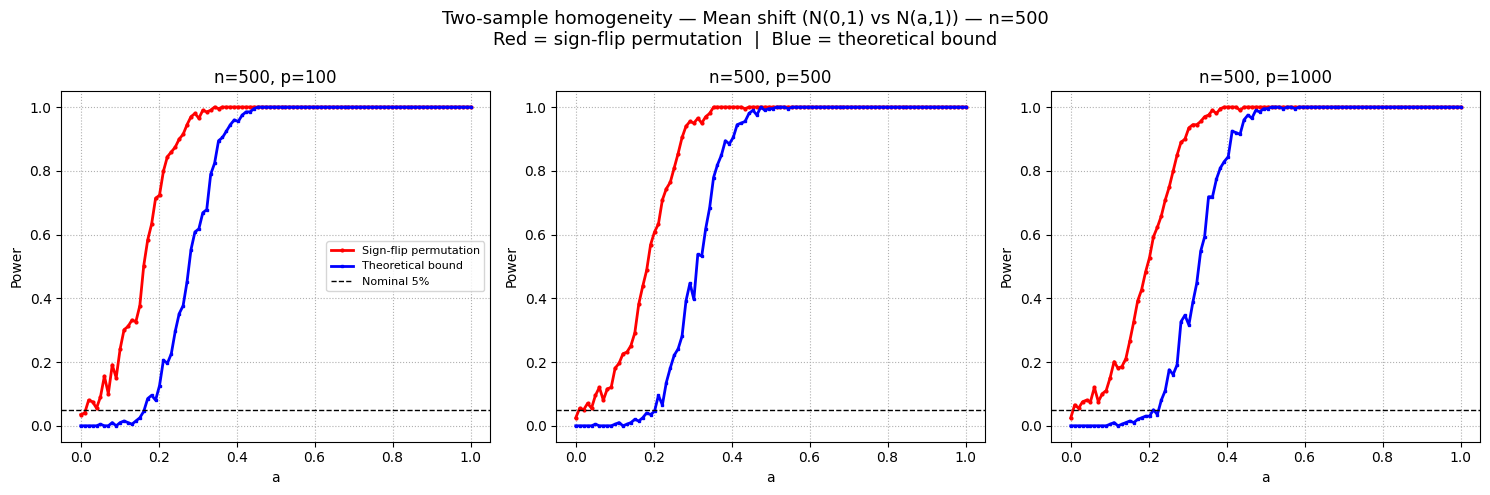

  -> power_two_sample_mean_n500.png sauvegardé


In [ ]:
n        = 500

print(f"{'='*60}\n  Two-sample homogeneity (cdf, mean shift) — n={n}\n{'='*60}")

for p in p_vals:
    x_grid = get_eval_grid(p, F0_ppf=stats.norm(loc=0, scale=1).ppf)
    task   = (gen_mean_shift, x_grid, n, p, a_grid, alpha, B, M)
    (n_res, p_res), pw_perm, pw_bound = run_two_sample_cdf_gpu(task)
    results_perm_mean[(n_res, p_res)]  = pw_perm
    results_bound_mean[(n_res, p_res)] = pw_bound

plot_single_n(results_perm_mean, results_bound_mean, n, p_vals, a_grid, save_dir,
              title='Two-sample homogeneity — Mean shift (N(0,1) vs N(a,1))',
              fname_base='power_two_sample_mean')

  Two-sample homogeneity (cdf, mean shift) — n=1000


  n=1000, p=1000: 100%|██████████| 100/100 [31:32<00:00, 18.92s/it]


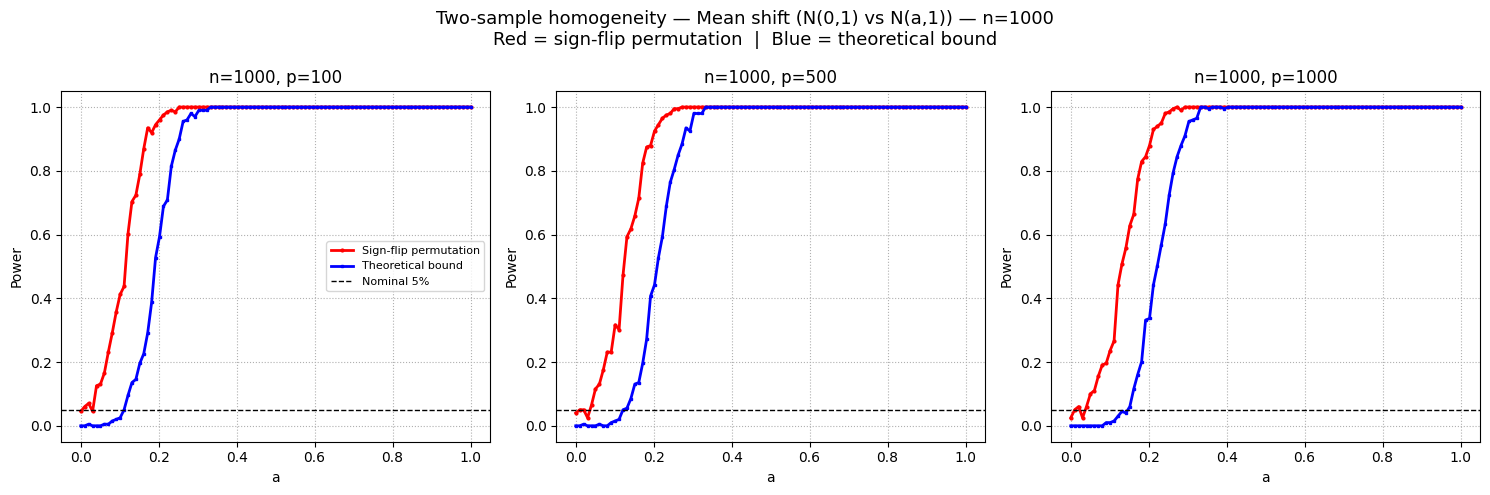

  -> power_two_sample_mean_n1000.png sauvegardé


In [ ]:
n = 1000

print(f"{'='*60}\n  Two-sample homogeneity (cdf, mean shift) — n={n}\n{'='*60}")

for p in p_vals:
    x_grid = get_eval_grid(p, F0_ppf=stats.norm(loc=0, scale=1).ppf)
    task   = (gen_mean_shift, x_grid, n, p, a_grid, alpha, B, M)
    (n_res, p_res), pw_perm, pw_bound = run_two_sample_cdf_gpu(task)
    results_perm_mean[(n_res, p_res)]  = pw_perm
    results_bound_mean[(n_res, p_res)] = pw_bound

plot_single_n(results_perm_mean, results_bound_mean, n, p_vals, a_grid, save_dir,
              title='Two-sample homogeneity — Mean shift (N(0,1) vs N(a,1))',
              fname_base='power_two_sample_mean')

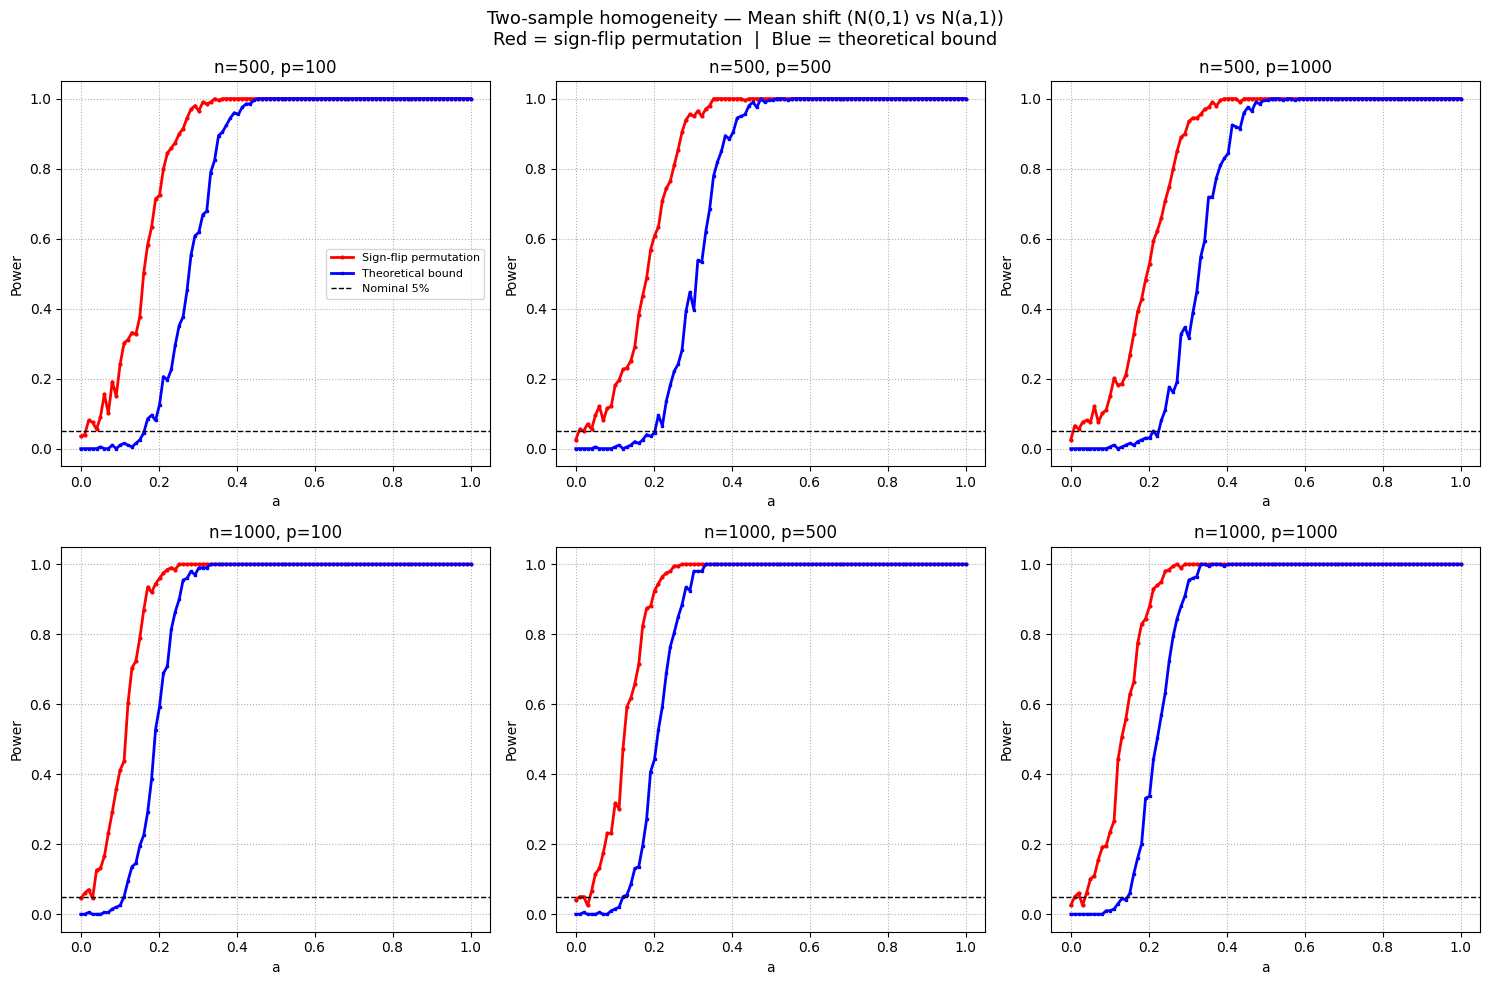

  -> power_two_sample_mean_all.png sauvegardé


In [ ]:
plot_all(results_perm_mean, results_bound_mean, n_vals, p_vals, a_grid, save_dir,
          title='Two-sample homogeneity — Mean shift (N(0,1) vs N(a,1))',
          fname_base='power_two_sample_mean')

---
## Variance shift

$X_i \sim N(0,1)$ fixed ; $Y_i \sim N(0, 1+a)$. $a=0 \Rightarrow$ same distribution ($H_0$), $a>0$ increases progressively the variance of $Y$.
---

  Two-sample homogeneity (cdf, variance shift) — n=500


  n=500, p=1000: 100%|██████████| 100/100 [25:12<00:00, 15.13s/it]


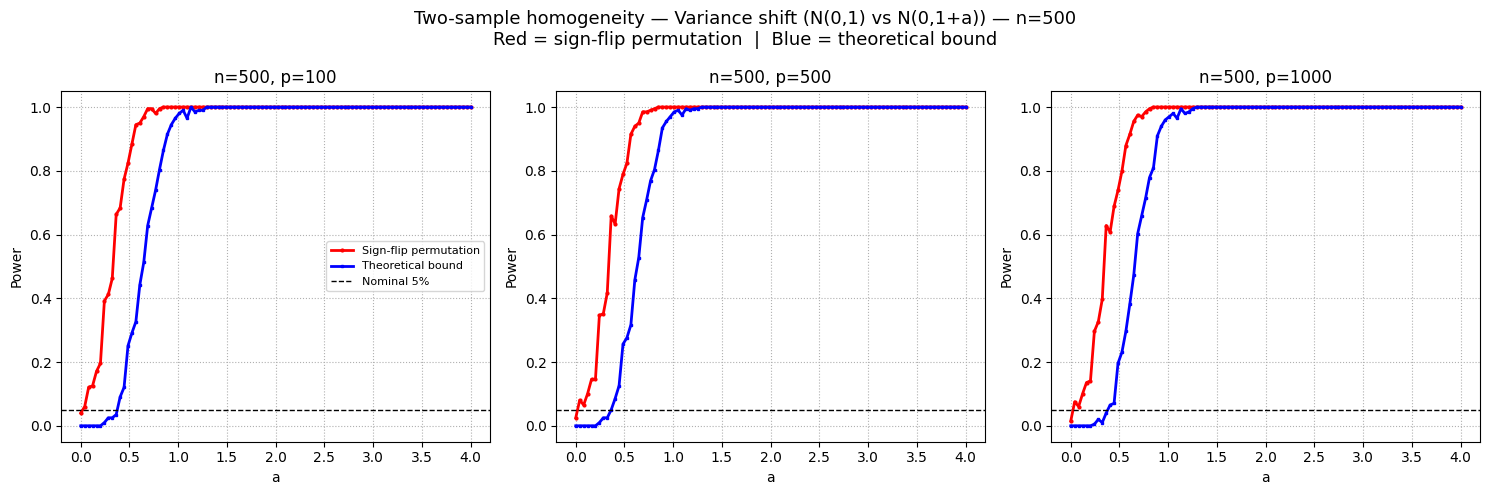

  -> power_two_sample_variance_n500.png sauvegardé


In [ ]:
save_dir = '/content/drive/MyDrive/Graphics4new'

results_perm_mix  = {}
results_bound_mix = {}

a_grid_var  = np.linspace(0, 4.0, 100)
B       = 299
M       = 199

n_vals  = [500, 1000]
p_vals  = [100, 500, 1000]

def gen_variance_shift(a, n, seed):
    """X_i ~ N(0,1),  Y_i ~ N(0, 1+a).  a=0 -> H0 (memes lois)."""
    rng = np.random.default_rng(seed)
    X = rng.normal(loc=0.0, scale=1.0, size=n)
    Y = rng.normal(loc=0.0, scale=np.sqrt(1.0 + a), size=n)
    return X, Y

n        = 500

print(f"{'='*60}\n  Two-sample homogeneity (cdf, variance shift) — n={n}\n{'='*60}")

results_perm_var  = {}
results_bound_var = {}

for p in p_vals:
    x_grid = get_eval_grid(p, F0_ppf=stats.norm(loc=0, scale=1).ppf)
    task   = (gen_variance_shift, x_grid, n, p, a_grid_var, alpha, B, M)
    (n_res, p_res), pw_perm, pw_bound = run_two_sample_cdf_gpu(task)
    results_perm_var[(n_res, p_res)]  = pw_perm
    results_bound_var[(n_res, p_res)] = pw_bound

plot_single_n(results_perm_var, results_bound_var, n, p_vals, a_grid_var, save_dir,
              title='Two-sample homogeneity — Variance shift (N(0,1) vs N(0,1+a))',
              fname_base='power_two_sample_variance')

  Two-sample homogeneity (cdf, variance shift) — n=1000


  n=1000, p=1000: 100%|██████████| 100/100 [31:34<00:00, 18.94s/it]


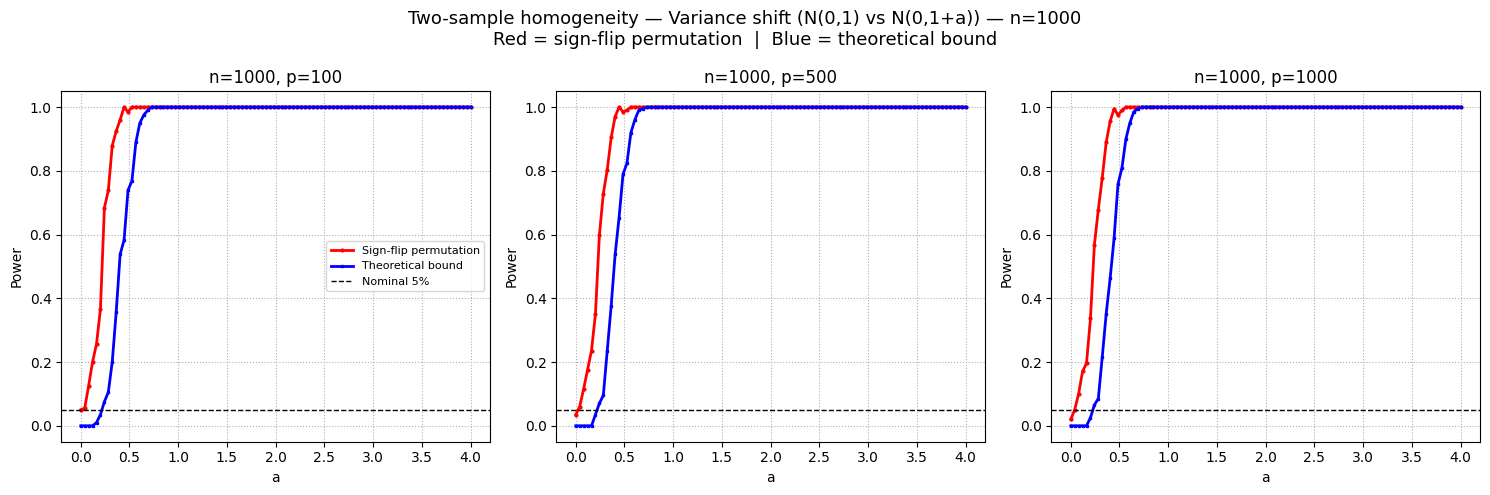

  -> power_two_sample_variance_n1000.png sauvegardé


In [ ]:
n = 1000

print(f"{'='*60}\n  Two-sample homogeneity (cdf, variance shift) — n={n}\n{'='*60}")

for p in p_vals:
    x_grid = get_eval_grid(p, F0_ppf=stats.norm(loc=0, scale=1).ppf)
    task   = (gen_variance_shift, x_grid, n, p, a_grid_var, alpha, B, M)
    (n_res, p_res), pw_perm, pw_bound = run_two_sample_cdf_gpu(task)
    results_perm_var[(n_res, p_res)]  = pw_perm
    results_bound_var[(n_res, p_res)] = pw_bound

plot_single_n(results_perm_var, results_bound_var, n, p_vals, a_grid_var, save_dir,
              title='Two-sample homogeneity — Variance shift (N(0,1) vs N(0,1+a))',
              fname_base='power_two_sample_variance')

In [ ]:
n_vals  = [500, 1000]
p_vals  = [100, 500, 1000]

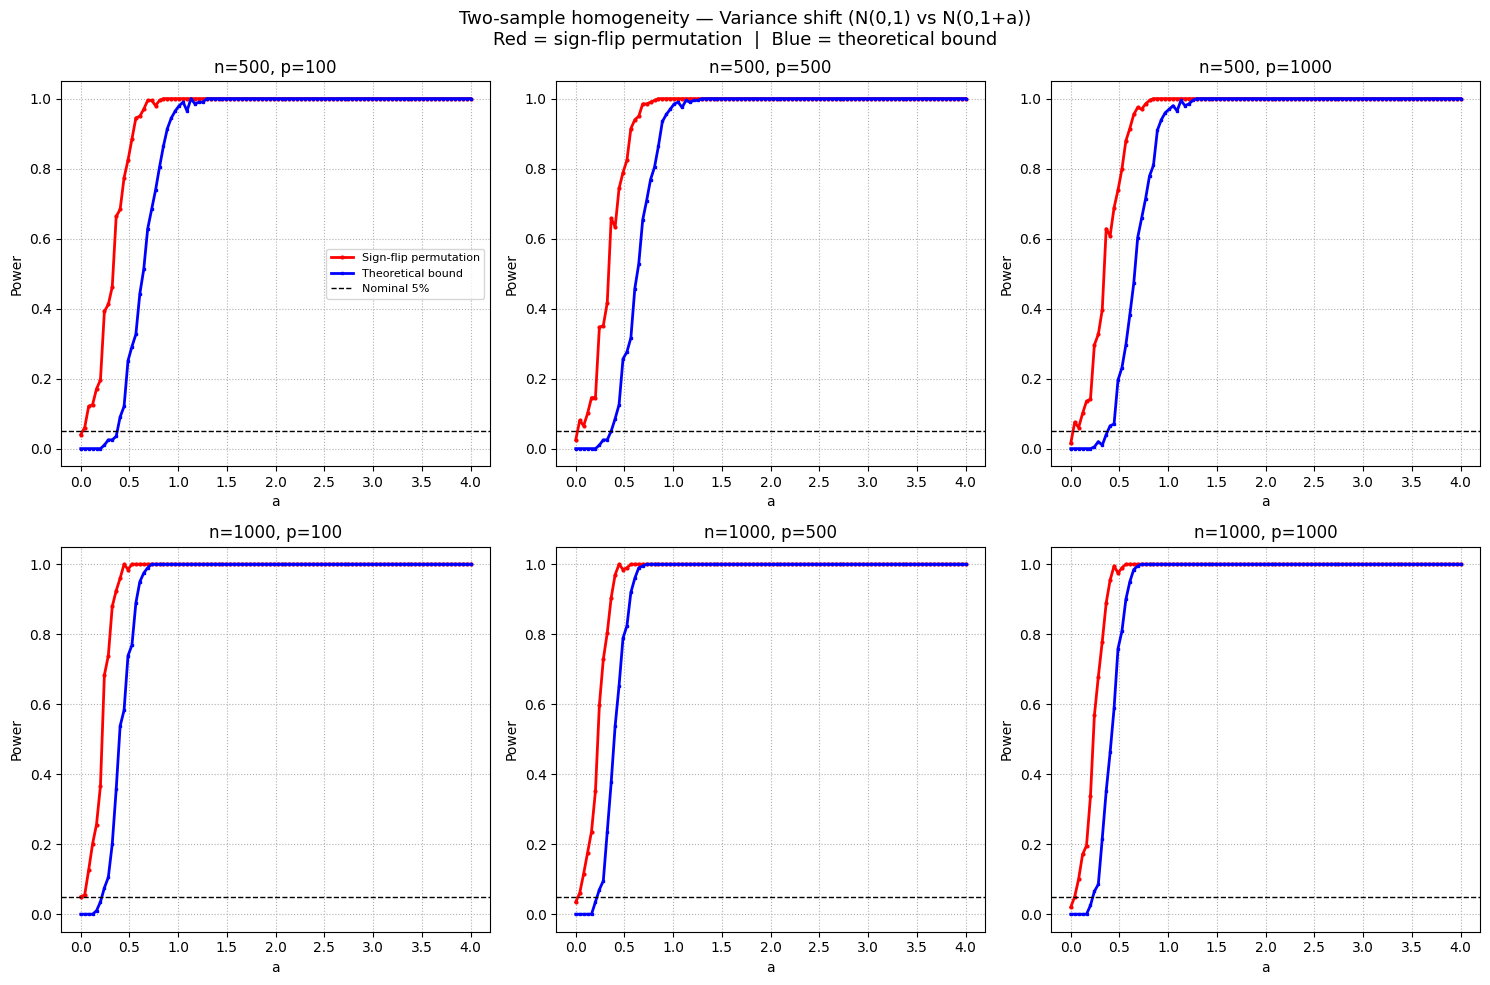

  -> power_two_sample_variance_all.png sauvegardé


In [ ]:
plot_all(results_perm_var, results_bound_var, n_vals, p_vals, a_grid_var, save_dir,
          title='Two-sample homogeneity — Variance shift (N(0,1) vs N(0,1+a))',
          fname_base='power_two_sample_variance')